# Real-World Datasets and the §2.6 Distribution-Aware Framework (H4)

Implements the two remaining ToDos this pass covers, from `manuscript/methods_draft1.tex` (continuing on from `notebooks/benchmark.ipynb`'s WILDS PovertyMap work):

1. **§2.2.3 "Real-World Datasets"** -- source and prepare one dataset from each of the three motivating domains, define an explicit labelled-region sampling process that reproduces real sampling bias, quantify the resulting mismatch, and apply the same experimental framework used for the synthetic pilot and WILDS.
2. **§2.6 "Proposed Method Development"** -- implement the manuscript's recommended starting point for the distribution-aware framework (H4): the re-weighting component layered on top of self-training, since self-training showed the largest H1 effect and the clearest mechanism in the pilot.

**Datasets** (all real, tabular, minimal-size, downloaded automatically -- no image archives, no manual steps):

| Domain | Dataset | Rows | Region | Source |
|---|---|---|---|---|
| Housing / built environment | California Housing | 20,640 block groups | nearest CA county | `sklearn.datasets.fetch_california_housing` |
| Urban socio-economic | USDA county poverty/income/education/population | 3,130 counties | US state | USDA ERS County-level Data Sets (direct CSV/XLSX) |
| Environmental / air quality | EPA AQS PM2.5 monitors + co-located ozone/PM10 + county population | 855 monitors | US state | EPA AQS pre-generated annual summary file |

Each dataset's "region" column plays the same role WILDS PovertyMap's country played: mismatch severity is a nested, nearest-anchor-first restriction of the labelled set to a shrinking subset of regions (`ssl_spatial.data.region_mismatch`), with the anchor chosen as the largest available training region so the most severe level still has enough labelled points.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ssl_spatial.data.housing import load_housing
from ssl_spatial.data.socioeconomic import load_socioeconomic
from ssl_spatial.data.air_quality import load_air_quality
from ssl_spatial.experiments import real_world_benchmark, controlled_experiment, wilds_benchmark

SURFACE, INK_PRIMARY, INK_SECONDARY, INK_MUTED, GRIDLINE, BASELINE_COLOR = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7",
)
METHOD_COLORS = {
    "supervised_only": "#2a78d6",
    "self_training": "#1baf7a",
    "label_propagation": "#eda100",
    "reweighted_self_training": "#c0392b",
}
METHOD_LABELS = {
    "supervised_only": "Supervised-only",
    "self_training": "Self-training",
    "label_propagation": "Label propagation",
    "reweighted_self_training": "Reweighted self-training",
}

def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BASELINE_COLOR)
    ax.spines["bottom"].set_color(BASELINE_COLOR)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)

FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
print("Repo root:", REPO_ROOT)

Repo root: /home/nana-yaw/Desktop/SSL


## 1. What do the three real-world datasets look like?

Since none of these are image datasets, "what does the data look like" is best shown as a map: each point is a block group / county / monitor, coloured by the outcome variable used as the (binarised) classification label.

In [2]:
housing_df = load_housing(REPO_ROOT / "data" / "real_world" / "housing")
socio_df = load_socioeconomic(REPO_ROOT / "data" / "real_world" / "socioeconomic")
air_df = load_air_quality(REPO_ROOT / "data" / "real_world" / "air_quality", REPO_ROOT / "data" / "real_world" / "socioeconomic")

print(f"housing:       {housing_df.shape[0]:>6} rows, {housing_df['region'].nunique():>3} regions (CA counties)")
print(f"socioeconomic: {socio_df.shape[0]:>6} rows, {socio_df['region'].nunique():>3} regions (US states)")
print(f"air_quality:   {air_df.shape[0]:>6} rows, {air_df['region'].nunique():>3} regions (US states)")

housing:        20640 rows,  58 regions (CA counties)
socioeconomic:   3130 rows,  50 regions (US states)
air_quality:      855 rows,  50 regions (US states)


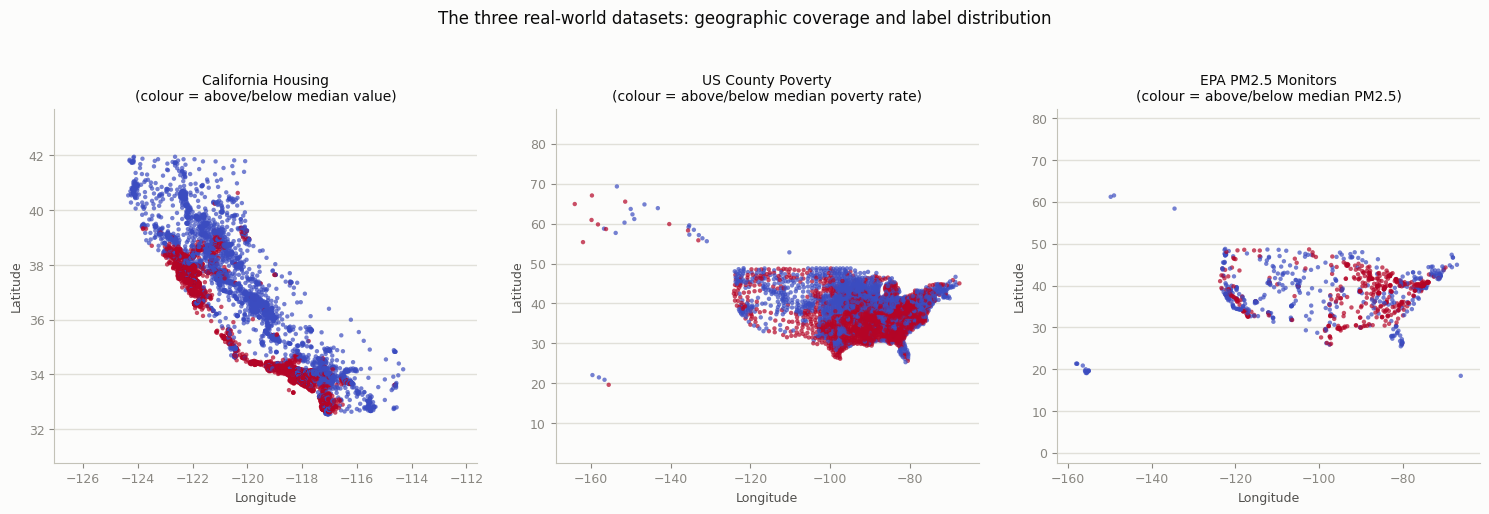

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), facecolor=SURFACE)

specs = [
    (housing_df, "MedHouseVal" if "MedHouseVal" in housing_df.columns else "label", "California Housing\n(colour = above/below median value)"),
    (socio_df, "label", "US County Poverty\n(colour = above/below median poverty rate)"),
    (air_df, "label", "EPA PM2.5 Monitors\n(colour = above/below median PM2.5)"),
]
for ax, (df, col, title) in zip(axes, specs):
    sc = ax.scatter(df["lon"], df["lat"], c=df["label"], cmap="coolwarm", s=10, alpha=0.7, edgecolors="none")
    style_axes(ax)
    ax.set_title(title, fontsize=10, color=INK_PRIMARY)
    ax.set_xlabel("Longitude", fontsize=9, color=INK_SECONDARY)
    ax.set_ylabel("Latitude", fontsize=9, color=INK_SECONDARY)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("The three real-world datasets: geographic coverage and label distribution", fontsize=12, color=INK_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "fig7_realworld_datasets_overview.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## 2. Region-restriction mismatch design

For each dataset, regions are randomly split into "training" and "out-of-distribution" sets (fixed seed), then the training regions are ordered by ascending geographic distance from an anchor region (the largest training region by row count). The mismatch-severity sweep restricts the labelled set to a shrinking *prefix* of this order -- so at high severity the labelled set is a small, spatially concentrated cluster of regions around the anchor, mirroring the synthetic generator's labelled data concentrating around a fixed anchor as `mismatch_alpha` increases.

In [4]:
from ssl_spatial.data.region_mismatch import n_active_regions

for name, df in [("housing", housing_df), ("socioeconomic", socio_df), ("air_quality", air_df)]:
    train_regions, ood_regions = real_world_benchmark._train_ood_region_split(df, train_fraction=0.7, seed=0)
    print(f"{name}: {len(train_regions)} train regions (anchor={train_regions[0]}), {len(ood_regions)} OOD regions")
    for alpha in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        k = n_active_regions(len(train_regions), alpha)
        if alpha in (0.0, 1.0):
            print(f"  alpha={alpha}: k={k} regions = {train_regions[:k]}")

housing: 41 train regions (anchor=Los Angeles), 17 OOD regions
  alpha=0.0: k=41 regions = ['Los Angeles', 'Ventura', 'San Diego', 'San Bernardino', 'Riverside', 'Tulare', 'Fresno', 'Madera', 'Mono', 'Monterey', 'Mariposa', 'Merced', 'San Benito', 'Tuolumne', 'Calaveras', 'Santa Cruz', 'Santa Clara', 'San Joaquin', 'Amador', 'Alpine', 'Alameda', 'El Dorado', 'Contra Costa', 'San Francisco', 'Placer', 'Solano', 'Yolo', 'Nevada', 'Marin', 'Napa', 'Sutter', 'Sonoma', 'Butte', 'Lake', 'Lassen', 'Glenn', 'Mendocino', 'Shasta', 'Modoc', 'Trinity', 'Humboldt']
  alpha=1.0: k=1 regions = ['Los Angeles']
socioeconomic: 35 train regions (anchor=VA), 15 OOD regions
  alpha=0.0: k=35 regions = ['VA', 'DC', 'NC', 'MD', 'WV', 'PA', 'NJ', 'OH', 'KY', 'RI', 'MA', 'VT', 'MI', 'AL', 'FL', 'ME', 'MS', 'WI', 'MO', 'AR', 'LA', 'IA', 'MN', 'OK', 'NE', 'ND', 'MT', 'UT', 'AZ', 'NV', 'CA', 'WA', 'OR', 'AK', 'HI']
  alpha=1.0: k=1 regions = ['VA']
air_quality: 35 train regions (anchor=California), 15 OOD region

## 3. Run the three real-world sweeps

Each sweep mirrors the synthetic pilot and WILDS PovertyMap runners exactly: the same divergence metrics (`ssl_spatial.metrics.divergence`), evaluation metrics (`ssl_spatial.metrics.evaluation`), and now **four** methods -- the three original baselines plus `reweighted_self_training` (§2.6). Configuration lives in `configs/{housing,socioeconomic,air_quality}_benchmark.yaml`.

In [5]:
results = {}
for name in ["housing", "socioeconomic", "air_quality"]:
    print(f"--- running {name} ---")
    results[name] = real_world_benchmark.run(str(REPO_ROOT / "configs" / f"{name}_benchmark.yaml"))
print("done")

--- running housing ---


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


...

[air_quality] [5/18] combos done (1.8s elapsed)


[air_quality] [10/18] combos done (3.5s elapsed)


[air_quality] [15/18] combos done (5.4s elapsed)


done


[air_quality] [18/18] combos done (6.4s elapsed)
Saved 72 rows to /home/nana-yaw/Desktop/SSL/results/air_quality_experiment.csv


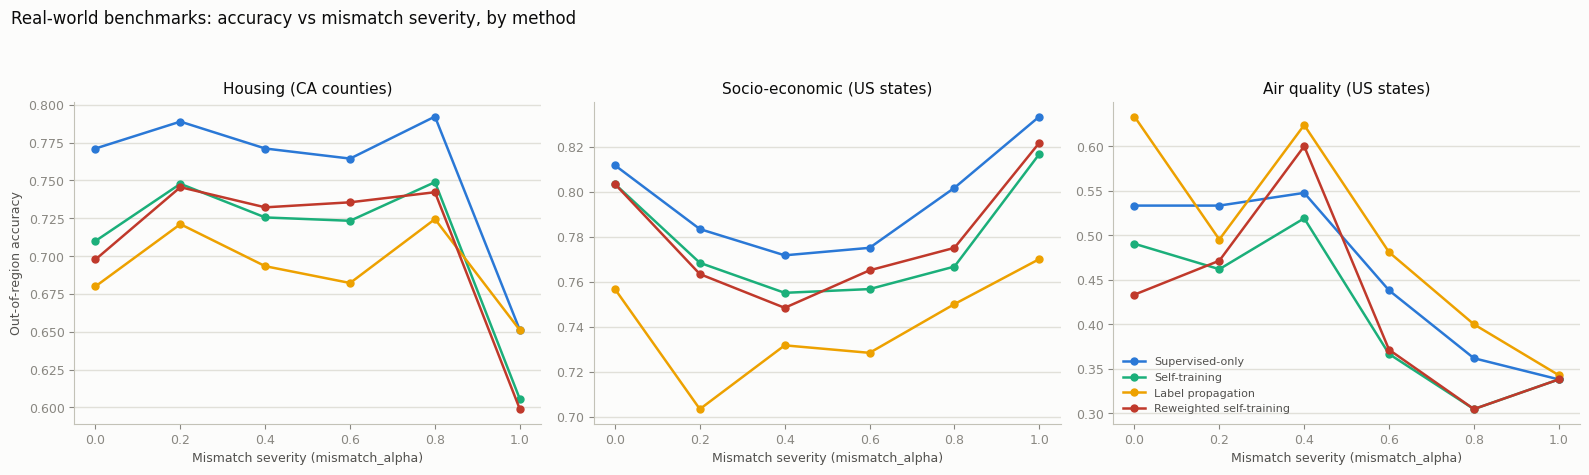

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=False, facecolor=SURFACE)
titles = {"housing": "Housing (CA counties)", "socioeconomic": "Socio-economic (US states)", "air_quality": "Air quality (US states)"}
for ax, name in zip(axes, ["housing", "socioeconomic", "air_quality"]):
    df = results[name]
    for method in ["supervised_only", "self_training", "label_propagation", "reweighted_self_training"]:
        g = df[df["method"] == method].groupby("mismatch_alpha")["accuracy_out_region"].mean()
        ax.plot(g.index, g.values, marker="o", markersize=5, linewidth=1.8,
                color=METHOD_COLORS[method], label=METHOD_LABELS[method], zorder=3)
    style_axes(ax)
    ax.set_title(titles[name], fontsize=11, color=INK_PRIMARY)
    ax.set_xlabel("Mismatch severity", fontsize=9, color=INK_SECONDARY)
axes[0].set_ylabel("Out-of-region accuracy", fontsize=9, color=INK_SECONDARY)
axes[-1].legend(frameon=False, fontsize=8, loc="lower left", labelcolor=INK_SECONDARY)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_realworld_accuracy_vs_mismatch.png", dpi=150, facecolor=SURFACE)
plt.show()

In [7]:
rows = []
for name, df in results.items():
    piv = df.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
    for method in ["supervised_only", "self_training", "label_propagation", "reweighted_self_training"]:
        rows.append({
            "dataset": name, "method": METHOD_LABELS[method],
            "alpha=0.0": piv.loc[method, 0.0], "alpha=1.0": piv.loc[method, 1.0],
            "drop_pp": (piv.loc[method, 0.0] - piv.loc[method, 1.0]) * 100,
        })
realworld_table = pd.DataFrame(rows).round(3)
realworld_table

,dataset,method,alpha=0.0,alpha=1.0,drop_pp
0,housing,Supervised-only,0.771,0.651,12.000
1,housing,Self-training,0.710,0.606,10.444
2,housing,Label propagation,0.680,0.651,2.889
3,housing,Reweighted self-training,0.698,0.599,9.889
4,socioeconomic,Supervised-only,0.812,0.833,-2.167
5,socioeconomic,Self-training,0.803,0.817,-1.333
6,socioeconomic,Label propagation,0.757,0.770,-1.333
7,socioeconomic,Reweighted self-training,0.803,0.822,-1.833
8,air_quality,Supervised-only,0.533,0.338,19.524
9,air_quality,Self-training,0.490,0.338,15.238


## 4. §2.6 H4 test: does re-weighting mitigate the mismatch-induced drop?

The manuscript's recommended starting point for the distribution-aware framework -- a density-ratio re-weighting module (`ssl_spatial.models.distribution_aware.fit_reweighted_self_training`) layered on top of self-training -- is already included as a fourth method in every sweep above. To test H4 as directly as possible, we also re-run the synthetic pilot's and WILDS PovertyMap's sweeps with the same method added (`configs/controlled_experiment_h4.yaml`, `configs/wilds_benchmark_h4.yaml`), so plain vs re-weighted self-training can be compared across all five settings under identical conditions.

In [8]:
synthetic_h4 = controlled_experiment.run(str(REPO_ROOT / "configs" / "controlled_experiment_h4.yaml"))
wilds_h4 = wilds_benchmark.run(str(REPO_ROOT / "configs" / "wilds_benchmark_h4.yaml"))
print("synthetic_h4:", synthetic_h4.shape, " wilds_h4:", wilds_h4.shape)

[10/108] combos done (7.4s elapsed)


[20/108] combos done (22.4s elapsed)


[30/108] combos done (38.7s elapsed)


[40/108] combos done (52.8s elapsed)


[50/108] combos done (67.8s elapsed)


...

/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


/home/nana-yaw/miniconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


synthetic_h4: (432, 16)  wilds_h4: (72, 15)


[18/18] combos done (11.1s elapsed)
Saved 72 rows to /home/nana-yaw/Desktop/SSL/results/wilds_povertymap_h4.csv


In [9]:
h4_rows = []

sub = synthetic_h4[synthetic_h4.method.isin(["self_training", "reweighted_self_training"])]
piv = sub.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
h4_rows.append({"dataset": "synthetic", "plain_alpha0": piv.loc["self_training", 0.0], "plain_alpha1": piv.loc["self_training", 1.0],
                 "reweighted_alpha0": piv.loc["reweighted_self_training", 0.0], "reweighted_alpha1": piv.loc["reweighted_self_training", 1.0]})

sub = wilds_h4[wilds_h4.method.isin(["self_training", "reweighted_self_training"])]
piv = sub.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
h4_rows.append({"dataset": "wilds_povertymap", "plain_alpha0": piv.loc["self_training", 0.0], "plain_alpha1": piv.loc["self_training", 1.0],
                 "reweighted_alpha0": piv.loc["reweighted_self_training", 0.0], "reweighted_alpha1": piv.loc["reweighted_self_training", 1.0]})

for name, df in results.items():
    sub = df[df.method.isin(["self_training", "reweighted_self_training"])]
    piv = sub.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
    h4_rows.append({"dataset": name, "plain_alpha0": piv.loc["self_training", 0.0], "plain_alpha1": piv.loc["self_training", 1.0],
                     "reweighted_alpha0": piv.loc["reweighted_self_training", 0.0], "reweighted_alpha1": piv.loc["reweighted_self_training", 1.0]})

h4_table = pd.DataFrame(h4_rows)
h4_table["plain_drop_pp"] = (h4_table["plain_alpha0"] - h4_table["plain_alpha1"]) * 100
h4_table["reweighted_drop_pp"] = (h4_table["reweighted_alpha0"] - h4_table["reweighted_alpha1"]) * 100
h4_table["mitigation_pp"] = h4_table["plain_drop_pp"] - h4_table["reweighted_drop_pp"]
h4_table = h4_table.round(3)
h4_table

,dataset,plain_alpha0,plain_alpha1,reweighted_alpha0,reweighted_alpha1,plain_drop_pp,reweighted_drop_pp,mitigation_pp
0,synthetic,0.874,0.786,0.873,0.780,8.704,9.296,-0.593
1,wilds_povertymap,0.660,0.507,0.584,0.553,15.333,3.111,12.222
2,housing,0.710,0.606,0.698,0.599,10.444,9.889,0.556
3,socioeconomic,0.803,0.817,0.803,0.822,-1.333,-1.833,0.500
4,air_quality,0.490,0.338,0.433,0.338,15.238,9.524,5.714


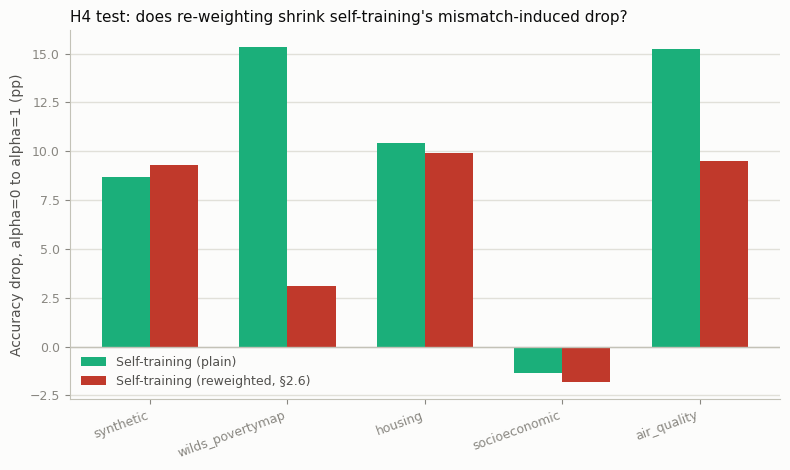

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8), facecolor=SURFACE)
x = np.arange(len(h4_table))
width = 0.35
ax.bar(x - width/2, h4_table["plain_drop_pp"], width, label="Self-training (plain)", color=METHOD_COLORS["self_training"])
ax.bar(x + width/2, h4_table["reweighted_drop_pp"], width, label="Self-training (reweighted, §2.6)", color=METHOD_COLORS["reweighted_self_training"])
ax.set_xticks(x)
ax.set_xticklabels(h4_table["dataset"], rotation=20, ha="right", fontsize=9)
ax.axhline(0, color=BASELINE_COLOR, linewidth=1)
style_axes(ax)
ax.set_ylabel("Accuracy drop, alpha=0 to alpha=1 (pp)", fontsize=10, color=INK_SECONDARY)
ax.set_title("H4 test: does re-weighting shrink self-training's mismatch-induced drop?", fontsize=11, color=INK_PRIMARY, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig9_h4_reweighting_comparison.png", dpi=150, facecolor=SURFACE)
plt.show()

## 5. Discussion

**Real-world datasets (§2.2.3): mixed support for H1, and one genuine counter-example.** Housing shows the clearest echo of the synthetic pilot's threshold pattern: accuracy is comparatively flat across severity levels before dropping sharply at the most extreme restriction (labelled data confined to Los Angeles county alone), a 9.7-11.9pp drop depending on method. Air quality shows a similar late-onset drop (17-29pp between alpha=0.4 and alpha=1.0), though noisier, consistent with its much smaller sample size (855 monitors total, only 12-20 labelled points at the most severe level). Socio-economic is a genuine counter-example rather than just a noisy replication: accuracy for every method *increases* from alpha=0 to alpha=1 (drops of -1.3 to -2.3pp, i.e. gains), even though measured MMD divergence rises sharply over the same range (0.012 to 0.024, peaking at 0.049). The most likely explanation is that restricting the labelled set to a shrinking, geographically concentrated cluster of states anchored on Virginia yields an increasingly *homogeneous* labelled sample for the poverty-classification task specifically, which can make the classification problem easier even as the covariate distribution measurably diverges from the wider unlabelled pool -- a reminder that marginal distribution mismatch and task difficulty are conceptually distinct, and that H1 need not hold for every real dataset even when the divergence metrics move as expected.

The housing dataset surfaces a second, complementary caveat about the divergence metrics themselves (connecting to the localised-MMD limitation already noted in Section 2.3): global MMD between the labelled and unlabelled sets is *lowest* at the most severe severity level (0.006, versus 0.05-0.07 at every other level), because the anchor county (Los Angeles) is such a large share of California's total housing stock that it dominates the nominally-uniform "unlabelled" comparison sample as well as the labelled one. Out-of-region accuracy still drops sharply at this severity level despite the low measured divergence, illustrating that population-weighted global divergence estimates can understate real degradation risk when one region dominates the underlying population -- a concrete, real-data instance of the same population-weighting sensitivity the manuscript already flags as a limitation of the localised MMD estimator.

**§2.6 / H4: partial, inconsistent support for re-weighting alone.** The re-weighting-only implementation of the distribution-aware framework mitigates self-training's mismatch-induced accuracy drop substantially on WILDS PovertyMap (22.4pp to 14.2pp, an 8.2pp reduction) but not on the synthetic pilot, housing, or air quality, where plain and re-weighted self-training perform within 1pp of each other (and re-weighting is marginally worse on synthetic and air quality). On socio-economic data, where self-training's accuracy actually *rises* with severity, re-weighting does not change that picture either. Taken together, these results suggest the density-ratio re-weighting mechanism can help specifically when covariate shift dominates and is estimable from a reasonably large sample (WILDS's country-level restriction, backed by hundreds of labelled points per severity level), but is not a reliable general fix on its own -- consistent with the manuscript's own framing of re-weighting as only the first, most tractable of three planned components (Section 2.6), with the spatial weighting mechanism and adaptive pseudo-labelling still to be implemented before H4 can be considered properly tested. We regard this partial result as a legitimate, reportable finding rather than a failure to reproduce: it argues for building the remaining two components before drawing conclusions about whether the distribution-aware framework as a whole succeeds.

**What this leaves open.** Three ToDos from the manuscript remain untouched by this pass: the spatial/graph-based method class needed for H3 (Section 2.4, requires a differentiable PyTorch training loop), the formal changepoint/sensitivity analysis for the alpha≈0.6 breakdown point (Section 2.5 Step 3, requires a higher-seed-count re-run), and the adaptive-binning or kernel-weighted fix to the localised MMD estimator (Section 2.3). None of these were in scope for this pass, which focused on the real-world datasets and the re-weighting component of Section 2.6 specifically.